<a href="https://colab.research.google.com/github/priyanshu-khariwal/Celebal_Technologies_Assignment/blob/main/week2_Priyanshu_khariwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla EA Deliveries and Production Data Analysis (2015–2025)

## Objective

The objective of this project is to build an end-to-end Machine Learning pipeline using Tesla deliveries and production data.

This project covers:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Cross Validation
- Hyperparameter Tuning
- Time Series Analysis
- Forecasting
- Model Evaluation

The goal is to predict Tesla vehicle deliveries and understand the factors influencing sales and production trends.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
from google.colab import files

uploaded_files = files.upload()

print("Upload completed. Available files:")
print(list(uploaded_files.keys()))

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv
Upload completed. Available files:
['tesla_deliveries_dataset_2015_2025.csv']


## Data Loading and Dataset Overview

In this section, we load the Tesla deliveries dataset and perform an initial inspection to understand its structure, features, and overall quality.

In [3]:
df = pd.read_csv(
    "tesla_deliveries_dataset_2015_2025.csv"
)

print("Dataset Loaded Successfully")
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Loaded Successfully

Shape of Dataset:
(2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [4]:
df.head(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


## Data Cleaning

Before building machine learning models, we check for missing values and duplicate records that may affect model performance.

In [7]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand trends, relationships, and patterns within Tesla's deliveries and production data.

In this section, we visualize:

- Deliveries by Vehicle Model
- Deliveries by Region
- Correlation Between Numerical Features
- Production vs Deliveries
- Tesla Deliveries Trend Over Time

**EDA 1 — Deliveries by Model**

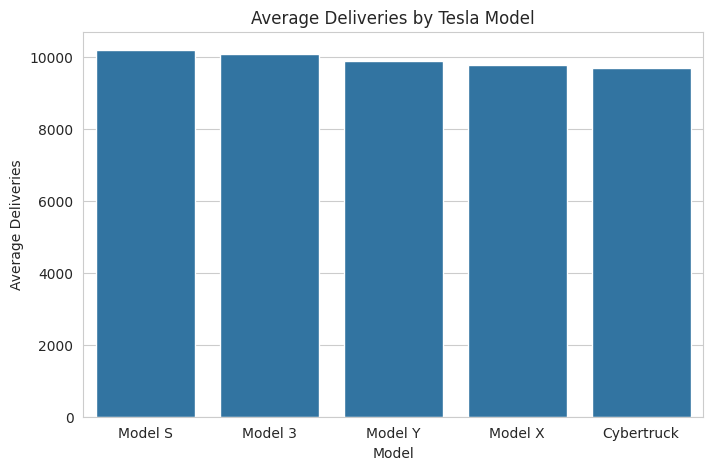

In [8]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=model_deliveries.index,
    y=model_deliveries.values
)

plt.title("Average Deliveries by Tesla Model")

plt.xlabel("Model")

plt.ylabel("Average Deliveries")

plt.show()

**EDA 2 — Deliveries by Region**

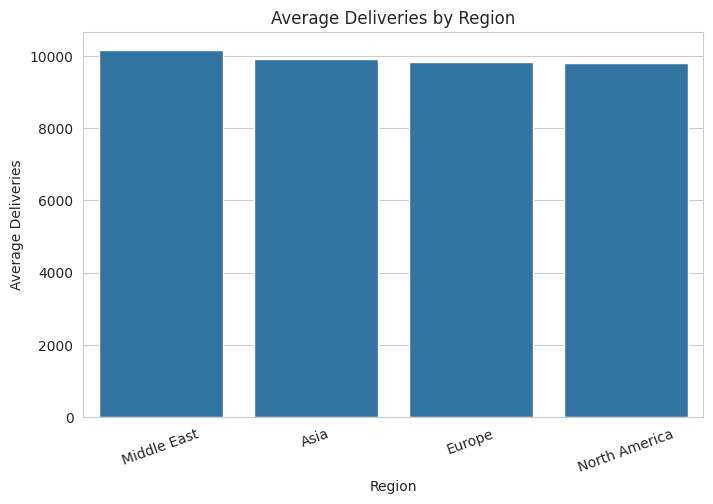

In [9]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_deliveries.index,
    y=region_deliveries.values
)

plt.title("Average Deliveries by Region")

plt.xlabel("Region")

plt.ylabel("Average Deliveries")

plt.xticks(rotation=20)

plt.show()

**EDA 3 — Correlation Heatmap**

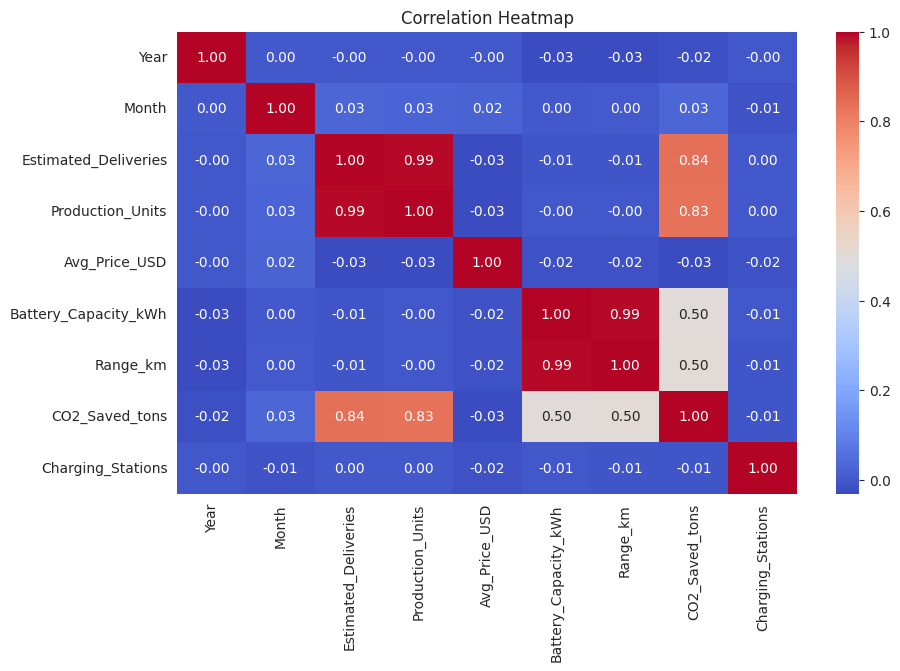

In [10]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**EDA 4 — Production vs Deliveries**

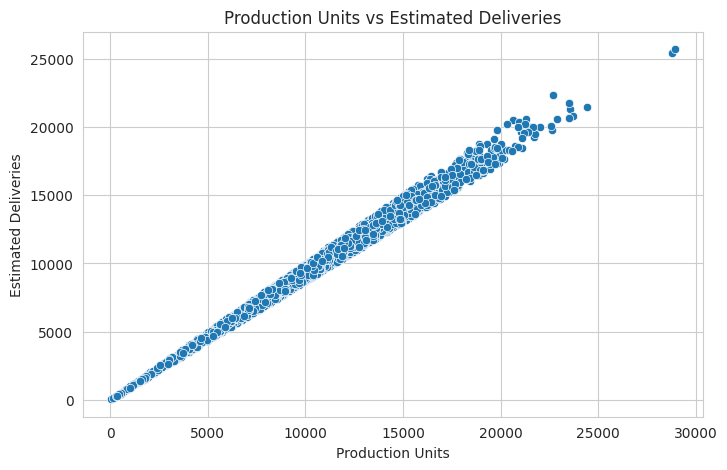

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["Production_Units"],
    y=df["Estimated_Deliveries"]
)

plt.title("Production Units vs Estimated Deliveries")

plt.xlabel("Production Units")

plt.ylabel("Estimated Deliveries")

plt.show()

**EDA 5 — Time Trend**

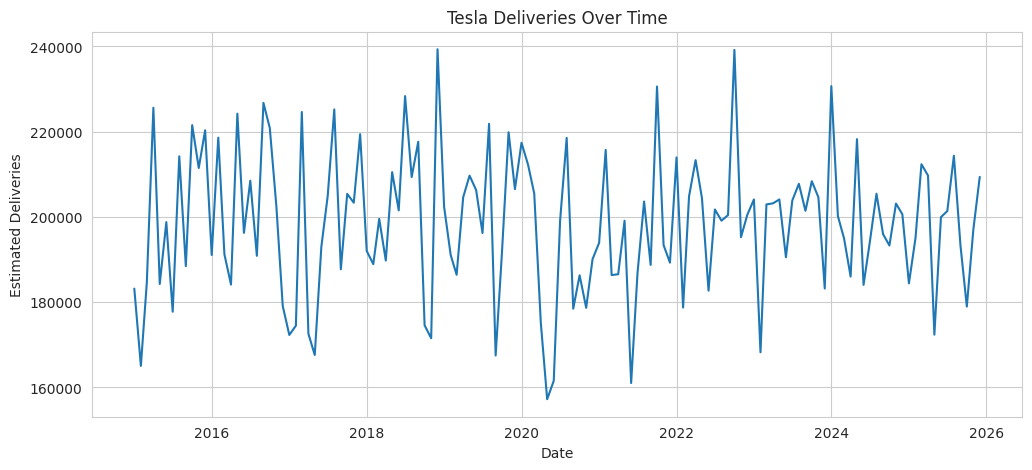

In [12]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Tesla Deliveries Over Time")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.show()

## Feature Engineering

Feature engineering transforms raw data into meaningful inputs for machine learning models.

In this section:

- Categorical variables are encoded
- Lag features are created
- Rolling statistics are calculated

**Encode Categorical Columns**

In [13]:
df_ml = df.copy()

encoder = LabelEncoder()

categorical_cols = [
    "Region",
    "Model",
    "Source_Type"
]

for col in categorical_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col])

print("Categorical features encoded successfully")
df_ml.head()

Categorical features encoded successfully


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


**Create Lag Feature**

In [14]:
df_ml = df_ml.sort_values(["Year", "Month"])

df_ml["Deliveries_Lag1"] = (
    df_ml["Estimated_Deliveries"]
    .shift(1)
)

df_ml["Deliveries_Lag1"].fillna(
    df_ml["Deliveries_Lag1"].mean(),
    inplace=True
)

print("Lag Feature Created")
df_ml[["Estimated_Deliveries", "Deliveries_Lag1"]].head()

Lag Feature Created


,Estimated_Deliveries,Deliveries_Lag1
644,10348,9921.649488
872,12446,10348.000000
904,10835,12446.000000
1199,8122,10835.000000
1228,13902,8122.000000


**Create Rolling Mean**

In [15]:
df_ml["Rolling_Mean_3"] = (
    df_ml["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df_ml["Rolling_Mean_3"].fillna(
    df_ml["Rolling_Mean_3"].mean(),
    inplace=True
)

print("Rolling Mean Feature Created")
df_ml[
    ["Estimated_Deliveries", "Rolling_Mean_3"]
].head()

Rolling Mean Feature Created


,Estimated_Deliveries,Rolling_Mean_3
644,10348,9921.864797
872,12446,9921.864797
904,10835,11209.666667
1199,8122,10467.666667
1228,13902,10953.000000


**Visualize Rolling Mean**

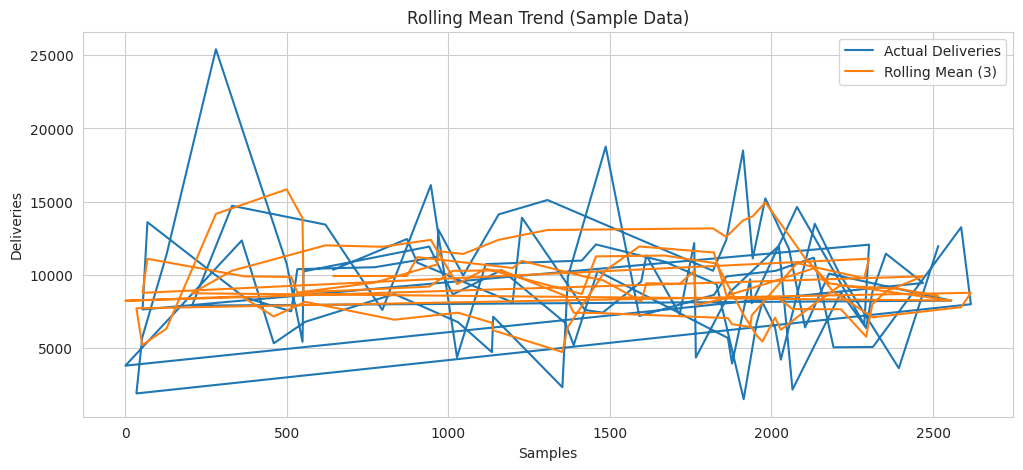

In [16]:
plt.figure(figsize=(12,5))

sample_df = df_ml.head(100)

plt.plot(
    sample_df["Estimated_Deliveries"],
    label="Actual Deliveries"
)

plt.plot(
    sample_df["Rolling_Mean_3"],
    label="Rolling Mean (3)"
)

plt.title("Rolling Mean Trend (Sample Data)")
plt.xlabel("Samples")
plt.ylabel("Deliveries")
plt.legend()

plt.show()

## Linear Regression Model

In this section, a Linear Regression model is trained to predict Tesla Estimated Deliveries.

The dataset is split chronologically to preserve the time-series nature of the data.

In [17]:
target = "Estimated_Deliveries"

features = [
    "Year",
    "Month",
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Source_Type",
    "Charging_Stations",
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]

X = df_ml[features]
y = df_ml[target]

print(X.shape)
print(y.shape)

(2640, 13)
(2640,)


**Chronological Split**

In [18]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 2112
Test Size: 528


**Train Linear Regression**

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


**Evaluation Metrics**

In [20]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 317.93
RMSE: 386.69
R² : 0.9889


**Actual vs Predicted Plot**

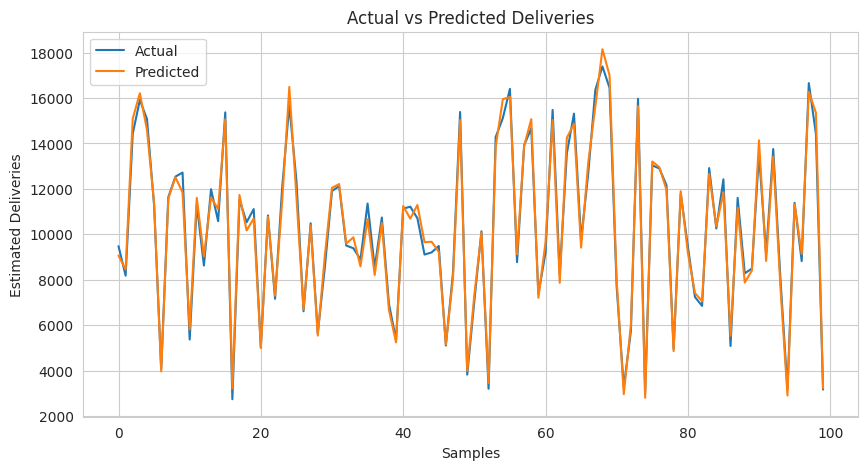

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    y_pred[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries")

plt.xlabel("Samples")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

## Cross Validation

Cross-validation helps evaluate the model's stability and generalization performance.

In [22]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(cv_scores.mean())

Cross Validation Scores:
[0.99079057 0.99051885 0.98970067 0.99023446 0.99037022]

Average R²:
0.990322953493124


## Hyperparameter Tuning

Random Forest Regressor is tuned using GridSearchCV to find the optimal parameters for prediction.

In [23]:
rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}


## Random Forest Regression Model

Using the optimized parameters obtained from GridSearchCV, a Random Forest model is trained and evaluated.

In [24]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


## Evaluation Cell

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest Results
---------------------
MAE : 337.18
RMSE: 414.67
R²  : 0.9872


## Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the Tesla deliveries time series is stationary.

In [26]:
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("P-Value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P-Value: 0.0
Series is Stationary


## Forecasting

Using the trained Linear Regression model, future Tesla delivery estimates are predicted on the test dataset.

In [27]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

forecast_df

,Actual,Predicted
0,9476,9063.528804
1,8179,8448.374747
2,14430,15095.699516
3,15912,16210.487814
4,15077,14598.067428
5,11280,11383.732099
6,4070,3964.099473
7,11636,11572.280772
8,12540,12514.509089
9,12717,11842.113838


# Business Insights

Based on the analysis of Tesla deliveries and production data:

1. Production Units have a very strong positive relationship with Estimated Deliveries.

2. Battery Capacity and Vehicle Range show moderate positive correlations.

3. Tesla deliveries remain relatively stable across different regions.

4. The machine learning model achieved high prediction accuracy with an R² score above 0.98.

5. Historical delivery patterns can effectively be used to forecast future deliveries.

# Conclusion

This project successfully built an end-to-end Machine Learning pipeline using Tesla Deliveries and Production Data (2015–2025).

The workflow included:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression Modeling
- Cross Validation
- Hyperparameter Tuning
- Random Forest Regression
- Stationarity Testing (ADF Test)
- Forecasting

The results demonstrate that Tesla delivery volumes can be predicted with high accuracy using production and operational features.

The final model achieved strong performance and provides valuable insights into delivery trends and forecasting.